# Plot RMS changes 

This notebook will be plotting the differences in RMS due to a synthetic magma body at depth

In [1]:
from pathlib import Path
from mtpy import MTData, MTCollection
from mtpy.modeling.plots.plot_modem_rms import PlotRMS
from mtpy.modeling.modem.data import Data
from mtpy.modeling.modem.residual import Residual

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import colorbar as mcb
from matplotlib import ticker

In [2]:
def calculate_rms(data_df, model_df):
    
    for col in ["z_xx", "z_xy", "z_yx", "z_yy", "t_zx", "t_zy"]:
        data_df[f"{col}_model_error"].fillna(1)
        with np.errstate(divide="ignore", invalid="ignore"):
            model_df[f"rms_{col.replace('_', '')}"] = np.abs(
                data_df[col] - model_df[col]
            ) / (np.real(data_df[f"{col}_model_error"]) * np.sqrt(2))
    return model_df

def calculate_rms_change(model_01_df, model_02_df):
    """ 
    Assumes 1 is the original, 2 is the new and returns model 2 as 2 - 1

    In that sense if the value is positive then 2 is larger rms and if
    the value is negative then 2 got smaller.
    """
    for col in ["z_xx", "z_xy", "z_yx", "z_yy", "t_zx", "t_zy"]:
        key = f"rms_{col.replace('_', '')}"
        with np.errstate(divide="ignore", invalid="ignore"):
            model_02_df[key] = 100 * (model_02_df[key] - model_01_df[key]) / model_01_df[key]
            # model_02_df[key] = (model_02_df[key] - model_01_df[key])

    return model_02_df

# Create a segmented colormap with white band in the middle
def create_segmented_bwr_cmap():
    # Define colors for segments (blue to white to red)
    blues = plt.cm.Blues(np.linspace(0.3, 1, 5))  # 5 shades of blue
    whites = np.array(
        [[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]]
    )  # 2 white segments for -0.1 to 0.1
    reds = plt.cm.Reds(np.linspace(0, 0.7, 5))  # 5 shades of red

    # Combine the colors
    colors_array = np.vstack([blues[::-1], whites, reds])

    # Create nodes for the segments (ensure we have white at -0.1 to 0.1)
    nodes = np.concatenate(
        [
            np.linspace(-1, -0.1, 6),  # 5 blue segments
            np.linspace(-0.1, 0.1, 2),  # white segment
            np.linspace(0.1, 1, 6),  # 5 red segments
        ]
    )

    # Create the colormap
    # cmap = colors.LinearSegmentedColormap.from_list('SegmentedBWR', list(zip(nodes, colors_array)))
    cmap = colors.LinearSegmentedColormap.from_list("SegmentedBWR", list(colors_array))
    return cmap

rms_cmap = create_segmented_bwr_cmap()

In [4]:
dat_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\clvf_tests")
fn_base = "clvf_m2"
test_files = list(dat_path.glob(f"{fn_base}*.dat"))

md_dict = {}
for fn in test_files:
    print(f"{fn.name}: exists = {fn.exists()}")
    survey = f"test_{fn.stem.split('_')[-1]}"
    md = Data()
    md_dict[survey] = md.read_data_file(fn).dataframe

## Read original data file in 
data_obj = Data()
data_df = data_obj.read_data_file(Path(
    r"c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\clvf_tests\cl_modem_data_z03_t02_tec_11.dat"
)).dataframe
md_dict["data"] = data_df

## Read preferred model response in 
model_data_obj = Data()
model_data_df = data_obj.read_data_file(
    Path(
        r"c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\clvf_tests\clvf_z03_t02_c02_smavg_042.dat"
    )
)

md_dict["model"] = model_data_df.dataframe

clvf_m2_test_01ohmm.dat: exists = True
clvf_m2_test_03ohmm.dat: exists = True
clvf_m2_test_07ohmm.dat: exists = True
clvf_m2_test_10ohmm.dat: exists = True
clvf_m2_test_15ohmm.dat: exists = True
clvf_m2_test_20ohmm.dat: exists = True
clvf_m2_test_25ohmm.dat: exists = True
clvf_m2_test_30ohmm.dat: exists = True
clvf_m2_test_35ohmm.dat: exists = True
clvf_m2_test_40ohmm.dat: exists = True
clvf_m2_test_50ohmm.dat: exists = True


In [5]:
# base_model_01 = calculate_rms(data_df.dataframe, model_data_df.dataframe)
base_model_01 = calculate_rms(md_dict["data"], md_dict["model"])

In [6]:
base_model_01[["rms_zxx", "rms_zxy", "rms_zyx", "rms_zyy", "rms_tzx", "rms_tzy"]].mean()

rms_zxx    1.225991
rms_zxy    1.140911
rms_zyx    1.164463
rms_zyy    1.209426
rms_tzx    0.737159
rms_tzy    0.754659
dtype: float64

In [7]:
rms_diff = {}
for key in md_dict.keys():
    if key in ["data", "model"]:
        continue
    try:
        model_df = calculate_rms(md_dict["data"], md_dict[key])
    except ValueError:
        print(f"Skipping {key}")
        continue
    delta_model_df = calculate_rms_change(base_model_01, model_df)
    # delta_model_df = delta_model_df[(delta_model_df.model_east > -200000) & (delta_model_df.model_east < 450000) & 
    #                                 (delta_model_df.model_north > -150000) & (delta_model_df.model_north < 300000)]
    rms_diff[key] = delta_model_df[["rms_zxx", "rms_zxy", "rms_zyx", "rms_zyy", "rms_tzx", "rms_tzy"]].mean().mean()



flipped x


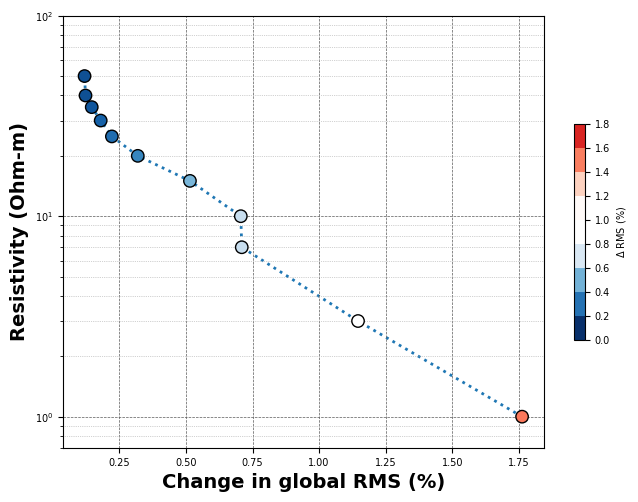

In [11]:
key_order = sorted([k for k in rms_diff.keys() if k not in ["model", "data"]])

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

plt.rcParamsDefault["font.size"] = 10

x = np.zeros(len(key_order))
y = np.zeros_like(x)

for index, key in enumerate(key_order):
    y[index] = float(key.split("_")[-1].replace("km", "").replace("ohmm", ""))
    x[index] = float(rms_diff[key])

if "m3" in fn_base or "m2" in fn_base:
    print("flipped x")
    x = np.sort(x)[::-1]

ax.plot(x, y, marker=None, ls=":", lw=2, zorder=1)
ax.scatter(x, y, c=x, cmap=rms_cmap, vmin=0, vmax=2, marker="o", s=80, edgecolors=(0,0,0), zorder=100)
# ax.scatter(x, y, c=None, cmap=None, vmin=-1, vmax=10, marker="s", s=80, edgecolors=(0,0,0), zorder=100)

if "doi" not in fn_base:
    ax.set_ylabel("Resistivity (Ohm-m)", fontdict={"size":14, "weight":"bold"})
    ax.set_xlabel("Change in global RMS (%)", fontdict={"size":14, "weight":"bold"})
    ax.set_yscale("log")
    ax.set_ylim(.7, 100)
else:
    # ax.set_ylabel("Bottom of R1 (km)", fontdict={"size":14, "weight":"bold"})
    ax.set_ylabel("Depth of Investigation (km)", fontdict={"size":14, "weight":"bold"})
    ax.set_xlabel("Change in global RMS (%)", fontdict={"size":14, "weight":"bold"})
    ax.set_ylim((50, 0))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

ax.grid(which="major", color=(.35, .35, .35), lw=.5, ls="--")
ax.grid(which="minor", color=(.65, .65, .65), lw=.5, ls=":")

cb_ax, _ = mcb.make_axes(ax, shrink=0.5)

cb_norm = colors.BoundaryNorm(
            np.arange(0, 2, .2),
            rms_cmap.N,
        )
cb = mcb.ColorbarBase(cb_ax, cmap=rms_cmap, norm=cb_norm, label=r"$\Delta$ RMS (%)")

plt.show()
fig.savefig(dat_path / f"{fn_base}_figure.png", dpi=300, bbox_inches="tight")

In [ ]:
for key in md_dict.keys():
    if key in ["data", "model"]:
        continue
    try:
        model_df = calculate_rms(md_dict["data"], md_dict[key])
    except ValueError:
        print(f"Skipping {key}")
        continue
    for base_df, base_id in zip([base_model_01], [40]):
        delta_model_df = calculate_rms_change(base_df, model_df)
        print(f"Mean RMS by component: {key}")
        print(
            f"{delta_model_df[['rms_zxx', 'rms_zyy', 'rms_zxy', 'rms_zyx', 'rms_tzx', 'rms_tzy']].mean()}"
        )
        print("\n")
        print(
            f"Mean RMS: {delta_model_df[['rms_zxx', 'rms_zyy', 'rms_zxy', 'rms_zyx', 'rms_tzx', 'rms_tzy']].mean().mean()}"
        )
        print("=" * 20)

In [9]:
from mtpy.modeling import StructuredGrid3D

for key in md_dict:
    if key in ["data", "model"]:
        continue
    model_fn = dat_path / f"{fn_base}_{key}.rho"
    if "doi" in fn_base:
        depth = float(key.split("_")[-1].replace("km", ""))*1000
    else:
        depth = 20000

    s = StructuredGrid3D()
    s.from_modem(model_fn)

    p = PlotRMS(calculate_rms_change(base_model_01, calculate_rms(md_dict["data"], md_dict[key])))
    p.plot_station = False
    p.dx = .02
    p.box_size = 30
    p.rms_min = -1.5
    p.rms_max = 1.5
    p.rms_step = .2
    p.rms_cmap = rms_cmap
    p.plot_per_station = False
    p.plot_per_period = False
    p.plot_map_components = False
    p.model_obj = s
    p.model_depth = depth
    p.plot_model = True
    p.plot()
    p.save_plot(dat_path / f"{fn_base}_{key}_rms_map.png", fig_dpi=300)

26:09:16T11:43:52 | WARNING | line:250 |mtpy.modeling.plots.plot_modem_rms | _plot_rms_map | Could not add base map because cannot convert float NaN to integer
26:09:16T11:43:53 | INFO | line:161 |mtpy.imaging.mtplot_tools.base | save_plot | Saved figure to: c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\clvf_tests\clvf_m2_test_01ohmm_rms_map.png
26:09:16T11:43:54 | WARNING | line:250 |mtpy.modeling.plots.plot_modem_rms | _plot_rms_map | Could not add base map because cannot convert float NaN to integer
26:09:16T11:43:54 | INFO | line:161 |mtpy.imaging.mtplot_tools.base | save_plot | Saved figure to: c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\clvf_tests\clvf_m2_test_03ohmm_rms_map.png
26:09:16T11:43:56 | WARNING | line:250 |mtpy.modeling.plots.plot_modem_rms | _plot_rms_map | Could not add base map because cannot convert float NaN to integer
26:09:16T11:43:56 | INFO | line:161 |mtpy.imaging.mtplot_tools.base | save_plot | Saved figure to: c:\Users\jpeacock\OneDrive - DO

In [86]:
a = calculate_rms(md_dict["data"], md_dict["model"])
b = calculate_rms(md_dict["data"], md_dict["test_01ohmm"])

In [93]:
np.nanmean(((1 - (b["rms_zxy"]/a["rms_zxy"]))*100))

np.float64(-0.6865052412096904)

In [94]:
calculate_rms_change(base_model_01, calculate_rms(md_dict["data"], md_dict["test_01ohmm"]))["rms_zxy"].mean()

np.float64(0.6865052412096907)